# A Fully Connected Neural Network (FCNN) for a classification task.
### Pre-processing 

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler

In [2]:
data = pd.read_csv("../data/credit_card_fraud_filtered.csv")
data.head(10)

y = data['fraud']
x = data.drop('fraud', axis=1)

In [3]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=81)

In [4]:
y.value_counts(normalize=True) * 100

fraud
0    93.595119
1     6.404881
Name: proportion, dtype: float64

In [5]:
y_train.value_counts(normalize=True) * 100

fraud
0    93.60755
1     6.39245
Name: proportion, dtype: float64

In [6]:
y_test.value_counts(normalize=True) * 100

fraud
0    93.545398
1     6.454602
Name: proportion, dtype: float64

In [7]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [8]:
x_train = torch.tensor(pd.DataFrame(x_train).values, dtype=torch.float32)
y_train = torch.tensor(pd.DataFrame(y_train).values, dtype=torch.float32)

train_dataset = TensorDataset(x_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, drop_last=False)

In [9]:
x_test = torch.tensor(pd.DataFrame(x_test).to_numpy(), dtype=torch.float32)
y_test = torch.tensor(pd.DataFrame(y_test).values, dtype=torch.float32)

test_dataset = TensorDataset(x_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, drop_last=False)

### FCNN with `softmax`

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim

class MyClassificationModel(nn.Module):
    def __init__(self, in_features, dropout_p=0.15):
        super().__init__()
        self.first_linear = nn.Linear(in_features, 60)
        self.first_relu = nn.ReLU()
        self.first_dropout = nn.Dropout(p=dropout_p)
        
        self.second_linear = nn.Linear(60, 20)
        self.second_relu = nn.ReLU()
        self.second_dropout = nn.Dropout(p=dropout_p)
        
        self.out_linear = nn.Linear(20, 2)
        # self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        y = self.first_dropout(self.first_relu(self.first_linear(x)))
        y = self.second_dropout(self.second_relu(self.second_linear(y)))
        y = self.out_linear(y)
        # y = self.softmax(y)  
        return y

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("mps")

num_features = train_dataset.tensors[0].shape[1] 
model = MyClassificationModel(in_features=num_features, dropout_p=0.15).to(device)
model = torch.compile(model)

# Расчет весов по обучающей выборке (до цикла!)
targets = train_dataset.tensors[1].long().view(-1)
count_0 = (targets == 0).sum().item()
count_1 = (targets == 1).sum().item()

# Вес редкого класса пропорционально выше (отправляем на то же устройство, что и модель)
class_weights = torch.tensor([1.0, count_0 / count_1], dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(model.parameters(), lr=0.0025) 

In [15]:
from sklearn.metrics import f1_score, classification_report

epochs = 1
train_f1_history = []
test_f1_history = []

for epoch in range(epochs):
    model.train()
    train_preds, train_targets = [], []
    
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device).long().view(-1)
        
        logits = model(x_batch)

        loss = criterion(logits, y_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        probs = torch.softmax(logits, dim=1)
        pred_labels = torch.argmax(probs, dim=1)
        train_preds.extend(pred_labels.cpu().numpy())
        train_targets.extend(y_batch.cpu().numpy())
        
    train_f1 = f1_score(train_targets, train_preds, average='binary')
    train_f1_history.append(train_f1)
    
    model.eval()
    test_preds, test_targets = [], []
    
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device).long().view(-1)
            
            probs = model(x_batch)
            pred_labels = torch.argmax(probs, dim=1)
            
            test_preds.extend(pred_labels.cpu().numpy())
            test_targets.extend(y_batch.cpu().numpy())
            
    test_f1 = f1_score(test_targets, test_preds, average='binary')
    test_f1_history.append(test_f1)
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d}/{epochs} | Train F1: {train_f1:.4f} | Test F1: {test_f1:.4f}")

Epoch 01/1 | Train F1: 0.9693 | Test F1: 0.9735


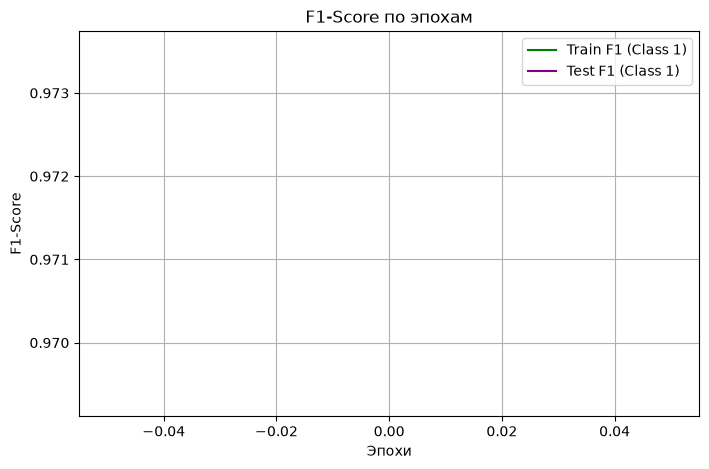

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_f1_history, label='Train F1 (Class 1)', color='green')
plt.plot(test_f1_history, label='Test F1 (Class 1)', color='purple')
plt.title('F1-Score по эпохам')
plt.xlabel('Эпохи')
plt.ylabel('F1-Score') 
plt.legend()
plt.grid(True)
plt.show()

In [17]:
from sklearn.metrics import confusion_matrix, classification_report

print("Classification Report:")
print(classification_report(test_targets, test_preds, target_names=['Class 0', 'Class 1']))

print("Confusion Matrix:")
print(confusion_matrix(test_targets, test_preds))

Classification Report:
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00    165537
     Class 1       0.95      1.00      0.97     11422

    accuracy                           1.00    176959
   macro avg       0.97      1.00      0.99    176959
weighted avg       1.00      1.00      1.00    176959

Confusion Matrix:
[[164916    621]
 [     0  11422]]


Архитектура полностью справилась с поставленной задачей с `f1-score` = 0.99, а взвешивание классов позволило не потерять ни одного объекта редкого класса (FN=0)

The architecture fully accomplished the task with an `f1-score` of 0.99, while class weighting ensured that not a single instance of the minority class was missed (FN=0).